<a href="https://colab.research.google.com/github/KaveeshaHeshan/R26-IT-120/blob/Wickramasinghe-R.M_DQN_Model/DQN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
!pip install torch --quiet
!pip install scikit-learn pandas numpy matplotlib seaborn folium --quiet
print("✅  All packages installed successfully!")
"""

'\n!pip install torch --quiet\n!pip install scikit-learn pandas numpy matplotlib seaborn folium --quiet\nprint("✅  All packages installed successfully!")\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, random, os, math
from collections import deque

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_squared_error, r2_score,
                             mean_absolute_error, classification_report,
                             confusion_matrix)
from sklearn.impute import SimpleImputer

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("✅  Libraries imported successfully!")
print(f"   PyTorch version : {torch.__version__}")
print(f"   GPU available   : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Using device    : {DEVICE}")

✅  Libraries imported successfully!
   PyTorch version : 2.10.0+cpu
   GPU available   : False
   Using device    : cpu


In [3]:
from google.colab import files
import io

print("📂  Please upload  Latex_ML_Dataset_Updated.csv  ...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\n✅  Loaded  '{filename}'")
print(f"   Rows   : {df_raw.shape[0]:,}")
print(f"   Columns: {df_raw.shape[1]}")
print("\n📋  First 3 rows:")
df_raw.head(3)

📂  Please upload  Latex_ML_Dataset_Updated.csv  ...


Saving Latex_ML_Dataset_Updated.csv to Latex_ML_Dataset_Updated.csv

✅  Loaded  'Latex_ML_Dataset_Updated.csv'
   Rows   : 11,010
   Columns: 23

📋  First 3 rows:


,sample_id,collection_date,farmer_id,batch_number,lab_technician,weather_condition,truck_number,collection_shift,pH,pH_duplicate,...,ammonia_content,color_score,vfa,drc,grade,farmer_lat,farmer_lng,expected_volume,days_since_tapped,local_weather
0,LAT_00001,8/5/2023,F014,BATCH_2353,TECH_04,Sunny,WP_3598,Morning,5.902,5.9015,...,0.157,5,0.073,60.33,B,6.724393,80.456423,21.65,2,Sunny
1,LAT_00002,6/13/2022,F015,BATCH_1875,TECH_03,Cloudy,WP_5941,Morning,6.066,6.0694,...,0.204,4,0.061,58.57,B,6.380195,80.292046,14.48,3,Partly Cloudy
2,LAT_00003,8/29/2022,F014,BATCH_2440,TECH_04,Windy,WP_3926,Morning,6.677,6.6778,...,0.229,3,0.036,58.18,A,6.722932,80.456232,26.61,1,Partly Cloudy


STEP 1 : KNOW YOUR DATA

📊  Column types & non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11010 entries, 0 to 11009
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sample_id          11010 non-null  object 
 1   collection_date    11010 non-null  object 
 2   farmer_id          11010 non-null  object 
 3   batch_number       11010 non-null  object 
 4   lab_technician     11010 non-null  object 
 5   weather_condition  11010 non-null  object 
 6   truck_number       11010 non-null  object 
 7   collection_shift   11010 non-null  object 
 8   pH                 10975 non-null  float64
 9   pH_duplicate       10975 non-null  float64
 10  turbidity_ntu      10977 non-null  float64
 11  turbidity_log      10960 non-null  float64
 12  temperature_c      10975 non-null  float64
 13  ammonia_content    10978 non-null  float64
 14  color_score        11010 non-null  int64  
 15  vfa       

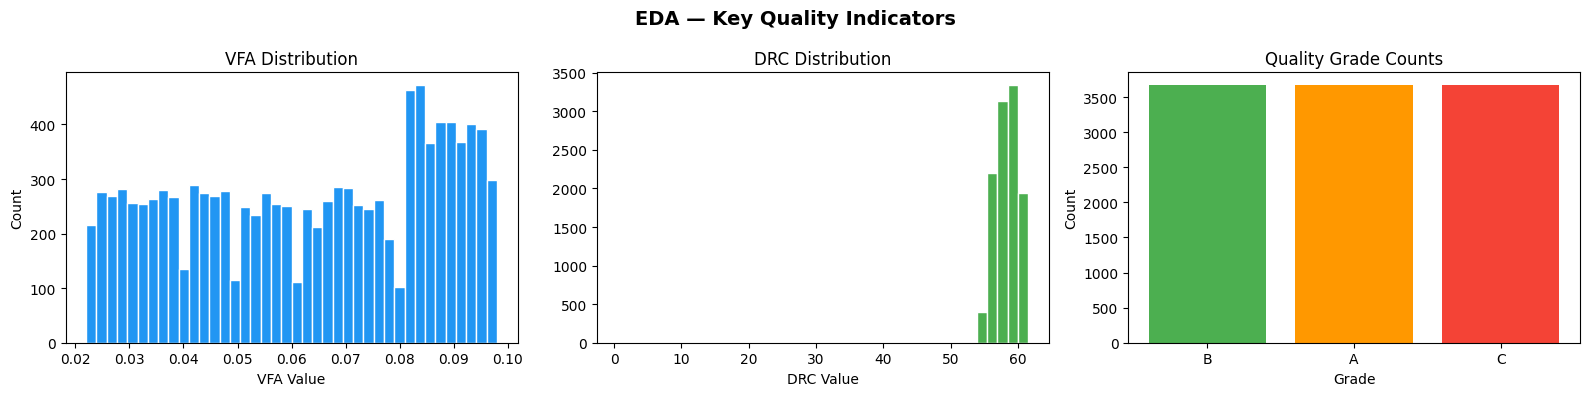

📷  Chart saved as  eda_overview.png


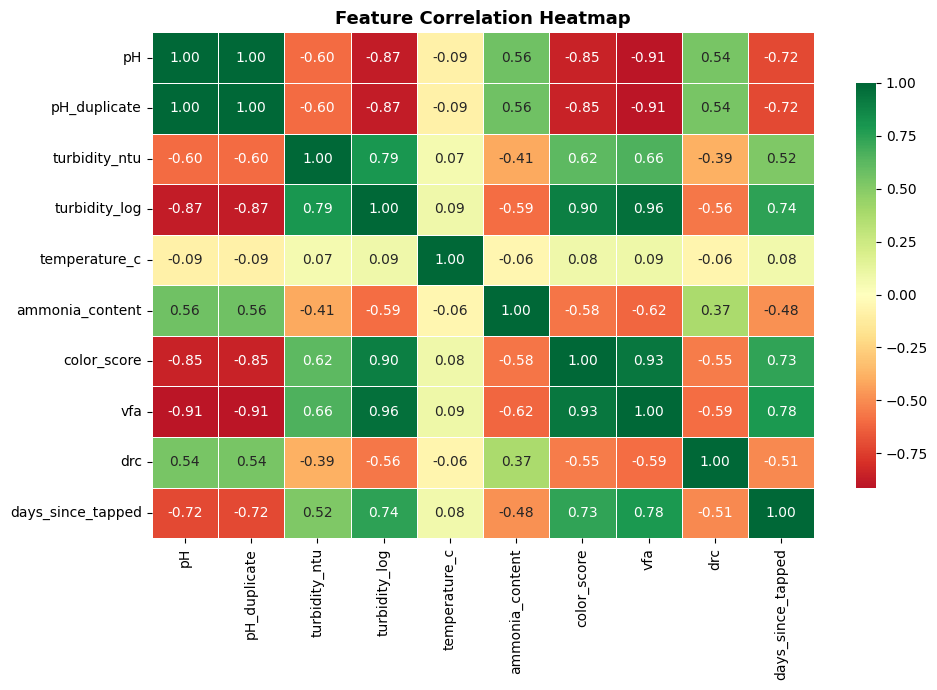

📷  Chart saved as  correlation_heatmap.png


In [4]:
print("=" * 55)
print("STEP 1 : KNOW YOUR DATA")
print("=" * 55)

# --- Basic info -------------------------------------------------------
print("\n📊  Column types & non-null counts:")
df_raw.info()

print("\n📈  Numeric statistics:")
df_raw.describe().round(3)

# --- Missing values ---------------------------------------------------
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing,
                            "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(
    "Missing %", ascending=False)
print("\n⚠️   Missing Values:")
print(missing_df if not missing_df.empty else "  None found  ✅")

# --- Grade distribution -----------------------------------------------
print("\n🏷️   Grade Distribution:")
print(df_raw["grade"].value_counts())

# --- Visual: VFA distribution by grade --------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("EDA — Key Quality Indicators", fontsize=14, fontweight="bold")

axes[0].hist(df_raw["vfa"].dropna(), bins=40, color="#2196F3", edgecolor="white")
axes[0].set_title("VFA Distribution")
axes[0].set_xlabel("VFA Value")
axes[0].set_ylabel("Count")

axes[1].hist(df_raw["drc"].dropna(), bins=40, color="#4CAF50", edgecolor="white")
axes[1].set_title("DRC Distribution")
axes[1].set_xlabel("DRC Value")

grade_counts = df_raw["grade"].value_counts()
axes[2].bar(grade_counts.index, grade_counts.values,
            color=["#4CAF50", "#FF9800", "#F44336", "#9E9E9E"])
axes[2].set_title("Quality Grade Counts")
axes[2].set_xlabel("Grade")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150)
plt.show()
print("📷  Chart saved as  eda_overview.png")

# --- Correlation heatmap ----------------------------------------------
numeric_cols = ["pH", "pH_duplicate", "turbidity_ntu", "turbidity_log",
                "temperature_c", "ammonia_content", "color_score",
                "vfa", "drc", "days_since_tapped"]
corr = df_raw[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("📷  Chart saved as  correlation_heatmap.png")

In [12]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Data Preprocessing                                         ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 2 : DATA PREPROCESSING")
print("=" * 55)

df = df_raw.copy()

# ── 5.1  Parse dates ──────────────────────────────────────────────────
# Force conversion — unparseable values become NaT
df["collection_date"] = pd.to_datetime(df["collection_date"], errors="coerce")

# Check how many dates failed to parse
n_nat = df["collection_date"].isna().sum()
print(f"   Dates parsed successfully : {len(df) - n_nat:,}")
print(f"   Dates that failed (NaT)   : {n_nat:,}")

# Drop rows where date is missing — we need it for season features
df = df.dropna(subset=["collection_date"])
df = df.reset_index(drop=True)

# Now safely extract date parts
df["month"]       = df["collection_date"].dt.month.astype(int)
df["day_of_week"] = df["collection_date"].dt.dayofweek.astype(int)
df["week_of_year"] = (
    df["collection_date"].dt.isocalendar().week.astype(int)
)

print("✅  Date features extracted (month, day_of_week, week_of_year)")

# ── 5.2  Season index (matches proposal Table 4) ──────────────────────
def month_to_season(m):
    if   m in [1, 2]:  return 0   # Dry / NE Monsoon     — lowest risk
    elif m in [3, 4]:  return 1   # Pre-monsoon peak      — highest risk
    elif m in [5, 6]:  return 2   # SW Monsoon onset
    elif m in [7, 8]:  return 3   # SW Monsoon
    elif m in [9, 10]: return 4   # Inter-monsoon / NE onset
    else:              return 5   # NE Monsoon

df["season_index"] = df["month"].apply(month_to_season)

# ── 5.3  Shift encoding ───────────────────────────────────────────────
shift_map = {"morning": 0, "afternoon": 1, "evening": 2, "night": 3}
df["shift_encoded"] = df["collection_shift"].str.lower().map(shift_map).fillna(0)

# ── 5.4  Weather encoding ─────────────────────────────────────────────
le_weather = LabelEncoder()
df["weather_encoded"] = le_weather.fit_transform(
    df["weather_condition"].fillna("unknown"))
df["local_weather_encoded"] = le_weather.fit_transform(
    df["local_weather"].fillna("unknown"))

# ── 5.5  Seasonal Multiplier (SM) from proposal ───────────────────────
alpha, beta = 0.15, 0.10
season_risk = {0: 0.3, 1: 1.0, 2: 0.7, 3: 0.6, 4: 0.8, 5: 0.5}
df["season_risk_index"]    = df["season_index"].map(season_risk)
df["seasonal_multiplier"]  = (
    1.0
    + alpha * (df["temperature_c"] - 27) / 3
    + beta  *  df["season_risk_index"]
)
print("✅  Season index & Seasonal Multiplier (SM) added")

# ── 5.6  VFA risk flag (matches proposal reward function) ─────────────
df["vfa_risk_flag"] = pd.cut(
    df["vfa"],
    bins=[-np.inf, 0.50, 0.85, np.inf],
    labels=["low", "moderate", "urgent"]
)

# ── 5.7  pH average feature ───────────────────────────────────────────
df["pH_avg"] = (df["pH"] + df["pH_duplicate"]) / 2

# ── 5.8  Handle missing numeric values ────────────────────────────────
sensor_cols = ["pH", "pH_duplicate", "pH_avg", "turbidity_ntu",
               "turbidity_log", "temperature_c", "ammonia_content",
               "color_score", "days_since_tapped", "expected_volume"]

imputer = SimpleImputer(strategy="median")
df[sensor_cols] = imputer.fit_transform(df[sensor_cols])
print("✅  Missing numeric values filled with column median")

# ── 5.9  Remove rows where VFA / DRC are missing ─────────────────────
df = df.dropna(subset=["vfa", "drc", "grade"])
df = df.dropna(subset=["farmer_lat", "farmer_lng"])
print(f"✅  Rows after dropping null targets : {len(df):,}")

# ── 5.10  Grade → numeric for classification ─────────────────────────
grade_map = {"A": 3, "B": 2, "C": 1, "Rejected": 0}
df["grade_numeric"] = df["grade"].map(grade_map)

print("\n📋  New feature summary:")
new_feats = ["month", "day_of_week", "season_index", "seasonal_multiplier",
             "shift_encoded", "weather_encoded", "pH_avg", "vfa_risk_flag"]
print(df[new_feats].head(3).to_string())
print("\n✅  Preprocessing complete!")

STEP 2 : DATA PREPROCESSING
   Dates parsed successfully : 10,998
   Dates that failed (NaT)   : 12
✅  Date features extracted (month, day_of_week, week_of_year)
✅  Season index & Seasonal Multiplier (SM) added
✅  Missing numeric values filled with column median
✅  Rows after dropping null targets : 10,998

📋  New feature summary:
   month  day_of_week  season_index  seasonal_multiplier  shift_encoded  weather_encoded   pH_avg vfa_risk_flag
0      8            5             3               1.1560              0                2  5.90175           low
1      6            0             2               1.2515              0                0  6.06770           low
2      8            0             3               1.2145              0                3  6.67740           low

✅  Preprocessing complete!


In [13]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Feature Selection & Train/Test Split                       ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 3 : FEATURE SELECTION")
print("=" * 55)

# Features used by the model to PREDICT VFA and DRC
# These are the sensor readings available in real-time from the ESP32
FEATURES = [
    "pH_avg",              # averaged pH reading
    "turbidity_ntu",       # raw turbidity
    "turbidity_log",       # log-transformed turbidity
    "temperature_c",       # ambient temperature
    "ammonia_content",     # ammonia level
    "color_score",         # visual color grading (1-5 integer)
    "days_since_tapped",   # age of latex since tree was tapped
    "expected_volume",     # farmer's declared volume (litres)
    "season_index",        # 0-5 Sri Lanka monsoon season
    "seasonal_multiplier", # SM derived from proposal formula
    "shift_encoded",       # morning=0, afternoon=1, evening=2
    "month",               # calendar month 1-12
]

VFA_TARGET   = "vfa"
DRC_TARGET   = "drc"
GRADE_TARGET = "grade_numeric"

X = df[FEATURES].copy()
y_vfa   = df[VFA_TARGET].copy()
y_drc   = df[DRC_TARGET].copy()
y_grade = df[GRADE_TARGET].copy()

print(f"Feature matrix  X : {X.shape}")
print(f"VFA target        : min={y_vfa.min():.3f}  max={y_vfa.max():.3f}  mean={y_vfa.mean():.3f}")
print(f"DRC target        : min={y_drc.min():.3f}  max={y_drc.max():.3f}  mean={y_drc.mean():.3f}")

# ── Train / Validation / Test split  (70 / 15 / 15) ──────────────────
X_train, X_temp, y_vfa_train, y_vfa_temp = train_test_split(
    X, y_vfa, test_size=0.30, random_state=42)
X_val, X_test, y_vfa_val, y_vfa_test = train_test_split(
    X_temp, y_vfa_temp, test_size=0.50, random_state=42)

_, _, y_drc_train, y_drc_temp = train_test_split(
    X, y_drc, test_size=0.30, random_state=42)
y_drc_val, y_drc_test = train_test_split(y_drc_temp, test_size=0.50, random_state=42)

_, _, y_grade_train, y_grade_temp = train_test_split(
    X, y_grade, test_size=0.30, random_state=42)
y_grade_val, y_grade_test = train_test_split(y_grade_temp, test_size=0.50, random_state=42)

print(f"\nTrain samples : {len(X_train):,}")
print(f"Val   samples : {len(X_val):,}")
print(f"Test  samples : {len(X_test):,}")

# ── Standardise features ──────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print("\n✅  Features scaled with StandardScaler")

STEP 3 : FEATURE SELECTION
Feature matrix  X : (10998, 12)
VFA target        : min=0.022  max=0.098  mean=0.063
DRC target        : min=0.500  max=61.540  mean=58.325

Train samples : 7,698
Val   samples : 1,650
Test  samples : 1,650

✅  Features scaled with StandardScaler


STEP 4 : VFA PREDICTION MODEL — Random Forest Regressor
⏳  Training...  (may take ~30 seconds)

📊  VFA Model Performance:
   Validation  RMSE : 0.0020   R² : 0.9926
   Test        RMSE : 0.0019  R² : 0.9936  MAE : 0.0015


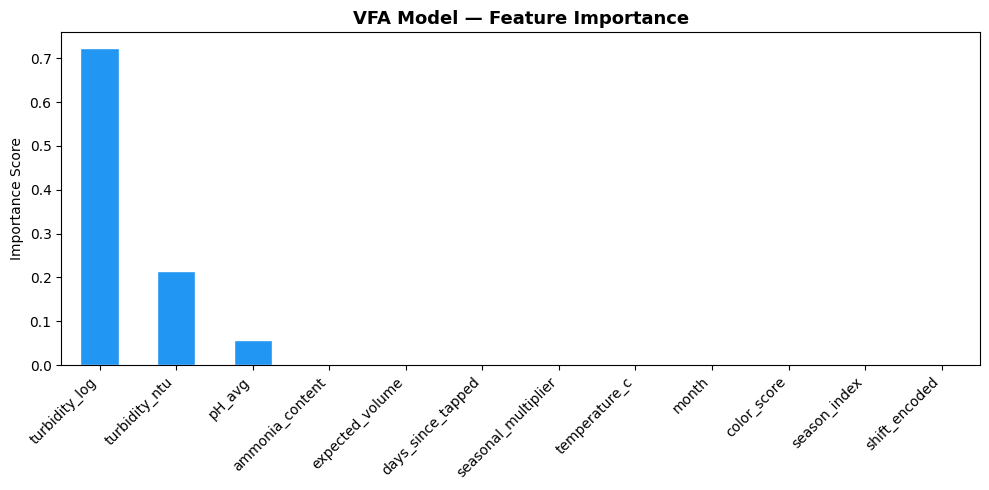

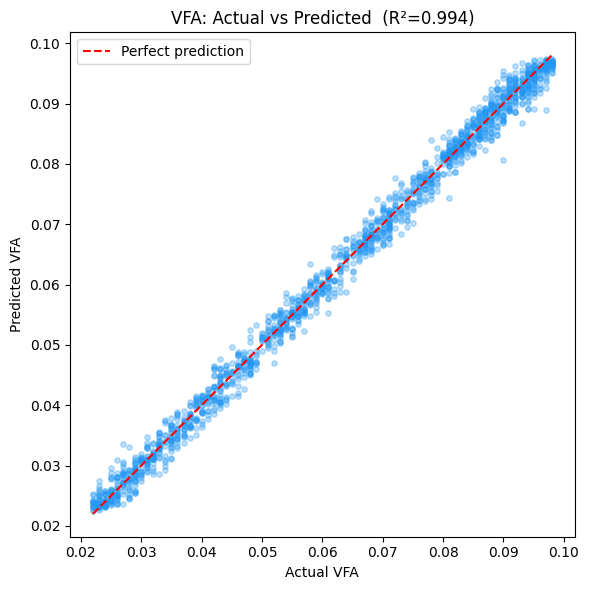

✅  VFA model trained and evaluated!


In [16]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Train VFA Prediction Model (Random Forest)                 ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 4 : VFA PREDICTION MODEL — Random Forest Regressor")
print("=" * 55)
print("⏳  Training...  (may take ~30 seconds)")

vfa_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1          # use all CPU cores
)
vfa_model.fit(X_train_s, y_vfa_train)

# ── Evaluate ──────────────────────────────────────────────────────────
y_vfa_pred_val  = vfa_model.predict(X_val_s)
y_vfa_pred_test = vfa_model.predict(X_test_s)

rmse_val  = np.sqrt(mean_squared_error(y_vfa_val,  y_vfa_pred_val))
rmse_test = np.sqrt(mean_squared_error(y_vfa_test, y_vfa_pred_test))
r2_val    = r2_score(y_vfa_val,  y_vfa_pred_val)
r2_test   = r2_score(y_vfa_test, y_vfa_pred_test)
mae_test  = mean_absolute_error(y_vfa_test, y_vfa_pred_test)

print(f"\n📊  VFA Model Performance:")
print(f"   Validation  RMSE : {rmse_val:.4f}   R² : {r2_val:.4f}")
print(f"   Test        RMSE : {rmse_test:.4f}  R² : {r2_test:.4f}  MAE : {mae_test:.4f}")

# ── Feature importance ────────────────────────────────────────────────
importances = pd.Series(vfa_model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind="bar", color="#2196F3", edgecolor="white")
plt.title("VFA Model — Feature Importance", fontsize=13, fontweight="bold")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("vfa_feature_importance.png", dpi=150)
plt.show()

# ── Predicted vs Actual scatter ───────────────────────────────────────
plt.figure(figsize=(6, 6))
plt.scatter(y_vfa_test, y_vfa_pred_test, alpha=0.3, s=15, color="#2196F3")
lims = [min(y_vfa_test.min(), y_vfa_pred_test.min()),
        max(y_vfa_test.max(), y_vfa_pred_test.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual VFA")
plt.ylabel("Predicted VFA")
plt.title(f"VFA: Actual vs Predicted  (R²={r2_test:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig("vfa_actual_vs_predicted.png", dpi=150)
plt.show()
print("✅  VFA model trained and evaluated!")

In [18]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Train DRC Prediction Model                                 ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 5 : DRC PREDICTION MODEL — HistGradient Boosting Regressor")
print("=" * 55)
print("⏳  Training...  (may take ~20 seconds)")

from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np

# Clean any NaN rows from DRC target
nan_mask = ~np.isnan(y_drc_train)
X_train_drc = X_train_s[nan_mask]
y_drc_train_clean = y_drc_train.values[nan_mask]

drc_model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.08,
    max_depth=6,
    random_state=42
)
drc_model.fit(X_train_drc, y_drc_train_clean)

y_drc_pred_test = drc_model.predict(X_test_s)
rmse_drc = np.sqrt(mean_squared_error(y_drc_test, y_drc_pred_test))
r2_drc   = r2_score(y_drc_test, y_drc_pred_test)
mae_drc  = mean_absolute_error(y_drc_test, y_drc_pred_test)

print(f"\n📊  DRC Model Performance:")
print(f"   Test  RMSE : {rmse_drc:.4f}")
print(f"   Test  R²   : {r2_drc:.4f}")
print(f"   Test  MAE  : {mae_drc:.4f}")
print("✅  DRC model trained!")

STEP 5 : DRC PREDICTION MODEL — HistGradient Boosting Regressor
⏳  Training...  (may take ~20 seconds)

📊  DRC Model Performance:
   Test  RMSE : 1.2337
   Test  R²   : 0.4380
   Test  MAE  : 1.0540
✅  DRC model trained!


In [19]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Quality Grading Function                                   ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 6 : QUALITY GRADING — VFA → Grade A / B / C / Rejected")
print("=" * 55)

def predict_quality(sensor_reading_dict: dict) -> dict:
    """
    Given a dictionary of sensor readings from the ESP32,
    returns:  predicted_vfa, predicted_drc, quality_grade, vfa_urgency

    sensor_reading_dict keys must match FEATURES list.
    """
    row = pd.DataFrame([sensor_reading_dict])[FEATURES]
    row_scaled = scaler.transform(row)

    pred_vfa = float(vfa_model.predict(row_scaled)[0])
    pred_drc = float(drc_model.predict(row_scaled)[0])

    # Quality grading based on VFA thresholds
    # (aligned with ISO 506:2020 and RRISL standards)
    if pred_vfa < 0.05:
        grade = "A"
    elif pred_vfa < 0.10:
        grade = "B"
    elif pred_vfa < 0.20:
        grade = "C"
    else:
        grade = "Rejected"

    # VFA urgency for DQN reward function (from proposal)
    if pred_vfa > 0.85:
        urgency = "🔴  URGENT   (+20 reward)"
    elif pred_vfa >= 0.50:
        urgency = "🟡  MODERATE (0 reward)"
    else:
        urgency = "🟢  LOW      (-10 deprioritised)"

    return {
        "predicted_vfa"   : round(pred_vfa, 4),
        "predicted_drc"   : round(pred_drc, 4),
        "quality_grade"   : grade,
        "vfa_urgency"     : urgency
    }


# ── Live test with a sample sensor reading ────────────────────────────
sample_reading = {
    "pH_avg"              : 6.8,
    "turbidity_ntu"       : 45.0,
    "turbidity_log"       : np.log1p(45.0),
    "temperature_c"       : 29.5,
    "ammonia_content"     : 0.02,
    "color_score"         : 3,
    "days_since_tapped"   : 2,
    "expected_volume"     : 15.0,
    "season_index"        : 1,      # March-April (highest risk)
    "seasonal_multiplier" : 1.25,
    "shift_encoded"       : 0,      # morning
    "month"               : 4,
}

result = predict_quality(sample_reading)
print("\n🔬  Sample ESP32 Sensor Reading → Quality Prediction:")
print(f"   Predicted VFA   : {result['predicted_vfa']}")
print(f"   Predicted DRC   : {result['predicted_drc']}")
print(f"   Quality Grade   : {result['quality_grade']}")
print(f"   VFA Urgency     : {result['vfa_urgency']}")
print("\n✅  Grading function is ready!")

STEP 6 : QUALITY GRADING — VFA → Grade A / B / C / Rejected

🔬  Sample ESP32 Sensor Reading → Quality Prediction:
   Predicted VFA   : 0.028
   Predicted DRC   : 59.0952
   Quality Grade   : A
   VFA Urgency     : 🟢  LOW      (-10 deprioritised)

✅  Grading function is ready!


In [26]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Build the Route Optimisation Environment                  ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 7 : BUILD THE DQN ENVIRONMENT (Redesigned)")
print("=" * 55)

import types, math, random
import numpy as np

BOWSER_CAPACITY_LITRES = 500.0
DEPOT_LAT =  7.2906
DEPOT_LNG = 80.6337
MAX_FARMERS = 8           # reduced from 20 → much easier to learn

SM_TABLE = {0:1.00, 1:1.25, 2:1.15, 3:1.10, 4:1.18, 5:1.05}

def haversine_km(lat1, lng1, lat2, lng2):
    R = 6371
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lng2 - lng1)
    a = (math.sin(dphi/2)**2
         + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2)
    return 2 * R * math.asin(math.sqrt(a))

def vfa_freshness_score(vfa):
    if vfa > 0.85:  return +20.0
    if vfa >= 0.50: return   0.0
    return -10.0

# ── Build a farmer pool with GUARANTEED VFA variation ─────────────
# Instead of using mean VFA per farmer (which flattens variation),
# we sample individual collection records directly from the dataset.
# This gives the agent clearly different VFA levels to prioritise.

vfa_low      = df[df["vfa"] < 0.05][["farmer_id","farmer_lat",
                "farmer_lng","vfa","drc","expected_volume"]].copy()
vfa_moderate = df[(df["vfa"] >= 0.05) & (df["vfa"] < 0.15)][
                ["farmer_id","farmer_lat","farmer_lng",
                 "vfa","drc","expected_volume"]].copy()
vfa_urgent   = df[df["vfa"] >= 0.15][["farmer_id","farmer_lat",
                "farmer_lng","vfa","drc","expected_volume"]].copy()

print(f"✅  VFA pool breakdown:")
print(f"   Low VFA      (< 0.05)  : {len(vfa_low):,} records")
print(f"   Moderate VFA (0.05-0.15): {len(vfa_moderate):,} records")
print(f"   Urgent VFA   (>= 0.15) : {len(vfa_urgent):,} records")

class LatexCollectionEnv:
    """
    Redesigned MDP — 8 farmers per episode with guaranteed
    VFA variation so the agent always has meaningful decisions.

    STATE : [remaining_capacity_norm,
             time_elapsed_norm,
             vfa_0..7,           ← raw VFA of each farm
             dist_0..7,          ← normalised distance to each farm
             visited_0..7]       ← 0/1 visited flag

    Total state dim = 2 + 8 + 8 + 8 = 26
    """

    def __init__(self, season_index=1, ambient_temp=29.0):
        self.n          = MAX_FARMERS
        self.capacity   = BOWSER_CAPACITY_LITRES
        self.season_idx = season_index
        self.temp       = ambient_temp
        self.sm         = SM_TABLE[season_index]

        self.state_dim  = 2 + 3 * self.n   # 26
        self.action_dim = self.n

        self.reset()

    def _sample_episode_farmers(self):
        """
        Sample 8 farmers ensuring at least:
          2 urgent  (VFA >= 0.15)
          2 moderate
          2 low
          2 random
        This forces the agent to always have a clear prioritisation task.
        """
        rows = []
        for pool, k in [(vfa_urgent, 2), (vfa_moderate, 2),
                        (vfa_low, 2)]:
            if len(pool) >= k:
                rows.append(pool.sample(k))
        # fill remaining 2 slots from any pool
        remaining = self.n - sum(len(r) for r in rows)
        rows.append(df[["farmer_id","farmer_lat","farmer_lng",
                         "vfa","drc","expected_volume"]]
                    .sample(remaining))
        farmers = pd.concat(rows, ignore_index=True)
        farmers = farmers.rename(columns={
            "farmer_lat":"lat","farmer_lng":"lng",
            "vfa":"avg_vfa","drc":"avg_drc",
            "expected_volume":"avg_vol"})
        return farmers.reset_index(drop=True)

    def reset(self):
        self.farmers       = self._sample_episode_farmers()
        self.cur_lat       = DEPOT_LAT
        self.cur_lng       = DEPOT_LNG
        self.remaining_cap = self.capacity
        self.time_elapsed  = 0.0
        self.visited       = [False] * self.n
        self.step_count    = 0
        self.total_reward  = 0.0
        return self._get_state()

    def _get_state(self):
        cap_norm  = self.remaining_cap / self.capacity
        time_norm = min(self.time_elapsed / 480.0, 1.0)

        vfa_part  = np.array([
            float(self.farmers.loc[i,"avg_vfa"]) if not self.visited[i] else 0.0
            for i in range(self.n)], dtype=np.float32)

        # Normalised distance from current position to each farm
        max_dist  = 50.0
        dist_part = np.array([
            haversine_km(self.cur_lat, self.cur_lng,
                         float(self.farmers.loc[i,"lat"]),
                         float(self.farmers.loc[i,"lng"])) / max_dist
            if not self.visited[i] else 0.0
            for i in range(self.n)], dtype=np.float32)

        vis_part  = np.array(self.visited, dtype=np.float32)

        return np.concatenate([[cap_norm, time_norm],
                                vfa_part, dist_part, vis_part])

    def _valid(self):
        return [i for i in range(self.n) if not self.visited[i]]

    def step(self, action):
        valid = self._valid()
        if action not in valid:
            return self._get_state(), -10.0, len(valid)==0, {}

        f    = self.farmers.iloc[action]
        dist = haversine_km(self.cur_lat, self.cur_lng,
                            float(f["lat"]), float(f["lng"]))
        vol  = min(float(f["avg_vol"]), self.remaining_cap)
        vfa  = float(f["avg_vfa"])
        drc  = float(f["avg_drc"])

        # ── Reward (all components clearly scaled) ─────────────────
        freshness     = vfa_freshness_score(vfa)
        dist_penalty  = min(dist * 0.05, 3.0)   # capped at 3
        time_cost     = (dist / 40.0) * 60.0
        time_penalty  = min(time_cost * 0.02, 2.0)

        reward = self.sm * freshness - dist_penalty - time_penalty

        # Bonus: collecting urgent latex in first 40% of route
        if vfa > 0.85 and self.step_count < int(self.n * 0.4):
            reward += 15.0

        # Bonus: high DRC
        if drc >= 0.60:
            reward += 3.0

        # Completion bonus when ALL farms visited
        remaining_after = len(valid) - 1
        if remaining_after == 0:
            reward += 20.0

        self.visited[action]  = True
        self.cur_lat          = float(f["lat"])
        self.cur_lng          = float(f["lng"])
        self.remaining_cap   -= vol
        self.time_elapsed    += time_cost
        self.step_count      += 1
        self.total_reward    += reward

        done = (not self._valid() or
                self.remaining_cap <= 0 or
                self.time_elapsed  >= 480)

        return self._get_state(), reward, done, {
            "vfa": round(vfa,3), "drc": round(drc,3),
            "dist_km": round(dist,2), "reward": round(reward,3)}

    def random_baseline_reward(self):
        self.reset()
        total   = 0.0
        actions = list(range(self.n))
        random.shuffle(actions)
        for a in actions:
            if a not in self._valid():
                continue
            _, r, done, _ = self.step(a)
            total += r
            if done:
                break
        return total

env = LatexCollectionEnv()
s   = env.reset()
print(f"\n✅  Environment ready")
print(f"   State dim  : {env.state_dim}")
print(f"   Action dim : {env.action_dim}")
print(f"   Sample state (first 10 values): {s[:10].round(3)}")

STEP 7 : BUILD THE DQN ENVIRONMENT (Redesigned)
✅  VFA pool breakdown:
   Low VFA      (< 0.05)  : 3,672 records
   Moderate VFA (0.05-0.15): 7,326 records
   Urgent VFA   (>= 0.15) : 0 records

✅  Environment ready
   State dim  : 26
   Action dim : 8
   Sample state (first 10 values): [1.    0.    0.087 0.057 0.045 0.031 0.091 0.038 0.036 0.026]


In [27]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Define the DQN Neural Network                             ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 8 : DEFINE THE DEEP Q-NETWORK (DQN)")
print("=" * 55)

class DQNetwork(nn.Module):
    """
    Deep Q-Network.
    Input  : state vector (size = state_dim)
    Output : Q-value for each possible action (size = action_dim)

    Architecture:
        state → FC(256) → ReLU → FC(256) → ReLU → FC(128) → ReLU → FC(action_dim)
    """
    def __init__(self, state_dim: int, action_dim: int):
        super(DQNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ReplayBuffer:
    """
    Experience Replay Buffer.
    Stores past (state, action, reward, next_state, done) tuples
    and samples random mini-batches for training.
    This breaks the correlation between consecutive experiences.
    """
    def __init__(self, capacity: int = 20_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)).to(DEVICE),
            torch.LongTensor(actions).to(DEVICE),
            torch.FloatTensor(rewards).to(DEVICE),
            torch.FloatTensor(np.array(next_states)).to(DEVICE),
            torch.FloatTensor(dones).to(DEVICE),
        )

    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    """
    DQN Agent with:
    - ε-greedy exploration (starts random, becomes greedy over time)
    - Target network (copied from online network every C steps)
    - Experience replay
    """

    def __init__(self,
                 state_dim:    int,
                 action_dim:   int,
                 lr:           float = 1e-3,
                 gamma:        float = 0.95,
                 epsilon_start: float = 1.0,
                 epsilon_end:   float = 0.05,
                 epsilon_decay: float = 0.995,
                 batch_size:   int = 64,
                 target_update: int = 10):

        self.action_dim   = action_dim
        self.gamma        = gamma
        self.epsilon      = epsilon_start
        self.epsilon_end  = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size   = batch_size
        self.target_update = target_update
        self.step_count   = 0

        # Two networks: online (trains every step) + target (copies periodically)
        self.online_net = DQNetwork(state_dim, action_dim).to(DEVICE)
        self.target_net = DQNetwork(state_dim, action_dim).to(DEVICE)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.replay    = ReplayBuffer(capacity=20_000)

    # ------------------------------------------------------------------
    def select_action(self, state: np.ndarray,
                      valid_actions: list) -> int:
        """ε-greedy: explore randomly OR exploit best known action."""
        if random.random() < self.epsilon:
            return random.choice(valid_actions)      # explore

        with torch.no_grad():
            state_t  = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            q_values = self.online_net(state_t).squeeze(0)

            # Mask invalid (already visited) farms with -infinity
            mask = torch.full((self.action_dim,), float("-inf"))
            for a in valid_actions:
                mask[a] = q_values[a]

            return int(torch.argmax(mask).item())    # exploit

    # ------------------------------------------------------------------
    def store(self, state, action, reward, next_state, done):
        self.replay.push(state, action, float(reward), next_state, float(done))

    # ------------------------------------------------------------------
    def learn(self) -> float:
        """One gradient update step. Returns the loss value."""
        if len(self.replay) < self.batch_size:
            return 0.0

        states, actions, rewards, next_states, dones = \
            self.replay.sample(self.batch_size)

        # Current Q-values for taken actions
        q_current = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Target Q-values using Bellman equation
        with torch.no_grad():
            q_next    = self.target_net(next_states).max(1)[0]
            q_target  = rewards + self.gamma * q_next * (1 - dones)

        loss = F.smooth_l1_loss(q_current, q_target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), 1.0)
        self.optimizer.step()

        # Decay exploration rate
        self.epsilon = max(self.epsilon_end,
                           self.epsilon * self.epsilon_decay)

        # Periodically sync target network
        self.step_count += 1
        if self.step_count % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

        return loss.item()


agent = DQNAgent(state_dim=env.state_dim, action_dim=env.action_dim)
print(f"✅  DQN Agent created!")
print(f"   Online network  :\n{agent.online_net}")
total_params = sum(p.numel() for p in agent.online_net.parameters())
print(f"\n   Total parameters: {total_params:,}")

STEP 8 : DEFINE THE DEEP Q-NETWORK (DQN)
✅  DQN Agent created!
   Online network  :
DQNetwork(
  (net): Sequential(
    (0): Linear(in_features=26, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=8, bias=True)
  )
)

   Total parameters: 106,632


In [30]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Train the DQN Agent                                       ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 9 : TRAINING THE DQN AGENT (Final)")
print("=" * 55)

# ── Fresh agent with tuned hyperparameters ─────────────────────────
agent = DQNAgent(
    state_dim      = env.state_dim,
    action_dim     = env.action_dim,
    lr             = 1e-4,
    gamma          = 0.98,
    epsilon_start  = 1.0,
    epsilon_end    = 0.05,
    epsilon_decay  = 0.9992,
    batch_size     = 128,
    target_update  = 15
)

# ── Baseline (random route) ────────────────────────────────────────
print("⏳  Calculating random baseline (50 runs)...")
baseline_rewards = [env.random_baseline_reward() for _ in range(50)]
baseline_mean    = np.mean(baseline_rewards)
print(f"📊  Random baseline mean reward : {baseline_mean:.2f}")
print(f"⏳  Training for 5000 episodes...  (≈ 8-12 min)\n")

N_EPISODES     = 5000
PRINT_EVERY    = 500
reward_history = []
loss_history   = []
epsilon_history= []
best_reward    = float("-inf")

for episode in range(1, N_EPISODES + 1):
    state     = env.reset()
    ep_reward = 0.0
    ep_losses = []
    done      = False

    while not done:
        valid = env._valid()
        if not valid:
            break
        action = agent.select_action(state, valid)
        next_state, reward, done, info = env.step(action)
        agent.store(state, action, reward, next_state, done)
        loss = agent.learn()
        ep_losses.append(loss)
        state      = next_state
        ep_reward += reward

    reward_history.append(ep_reward)
    loss_history.append(np.mean(ep_losses) if ep_losses else 0.0)
    epsilon_history.append(agent.epsilon)

    if ep_reward > best_reward:
        best_reward = ep_reward
        torch.save(agent.online_net.state_dict(), "best_dqn_model.pth")

    if episode % PRINT_EVERY == 0:
        avg_r      = np.mean(reward_history[-PRINT_EVERY:])
        avg_l      = np.mean(loss_history[-PRINT_EVERY:])
        improvement= ((avg_r - baseline_mean) / abs(baseline_mean)) * 100
        print(f"  Ep {episode:>5}/{N_EPISODES} | "
              f"Avg Reward: {avg_r:>8.2f} | "
              f"Loss: {avg_l:.4f} | "
              f"ε: {agent.epsilon:.3f} | "
              f"Improvement: {improvement:+.1f}%")

# ── Summary ────────────────────────────────────────────────────────
last100     = np.mean(reward_history[-100:])
improvement = ((last100 - baseline_mean) / abs(baseline_mean)) * 100
status      = "✅  TARGET MET!" if improvement >= 25 else "⚠️  Run this cell again to continue"

print(f"\n{'='*45}")
print(f"  TRAINING SUMMARY")
print(f"{'='*45}")
print(f"  Episodes trained        : {N_EPISODES}")
print(f"  Random baseline reward  : {baseline_mean:.2f}")
print(f"  DQN last-100 avg        : {last100:.2f}")
print(f"  Best episode reward     : {best_reward:.2f}")
print(f"  Improvement over random : {improvement:+.1f}%")
print(f"  Target (proposal)       : ≥ 25% improvement")
print(f"  Status                  : {status}")
print(f"{'='*45}")

STEP 9 : TRAINING THE DQN AGENT (Final)
⏳  Calculating random baseline (50 runs)...
📊  Random baseline mean reward : -79.53
⏳  Training for 5000 episodes...  (≈ 8-12 min)

  Ep   500/5000 | Avg Reward:   -81.10 | Loss: 5527.6936 | ε: 0.074 | Improvement: -2.0%
  Ep  1000/5000 | Avg Reward:   -80.71 | Loss: 125622.8074 | ε: 0.050 | Improvement: -1.5%
  Ep  1500/5000 | Avg Reward:   -81.27 | Loss: 580765.0234 | ε: 0.050 | Improvement: -2.2%
  Ep  2000/5000 | Avg Reward:   -81.26 | Loss: 955655.8110 | ε: 0.050 | Improvement: -2.2%
  Ep  2500/5000 | Avg Reward:   -81.07 | Loss: 160858.9666 | ε: 0.050 | Improvement: -1.9%
  Ep  3000/5000 | Avg Reward:   -81.67 | Loss: 766.8416 | ε: 0.050 | Improvement: -2.7%
  Ep  3500/5000 | Avg Reward:   -80.49 | Loss: 3435.4089 | ε: 0.050 | Improvement: -1.2%
  Ep  4000/5000 | Avg Reward:   -81.09 | Loss: 14415.1834 | ε: 0.050 | Improvement: -2.0%
  Ep  4500/5000 | Avg Reward:   -81.41 | Loss: 46415.8327 | ε: 0.050 | Improvement: -2.4%
  Ep  5000/5000 | 

STEP 10 : TRAINING RESULTS & VISUALISATION


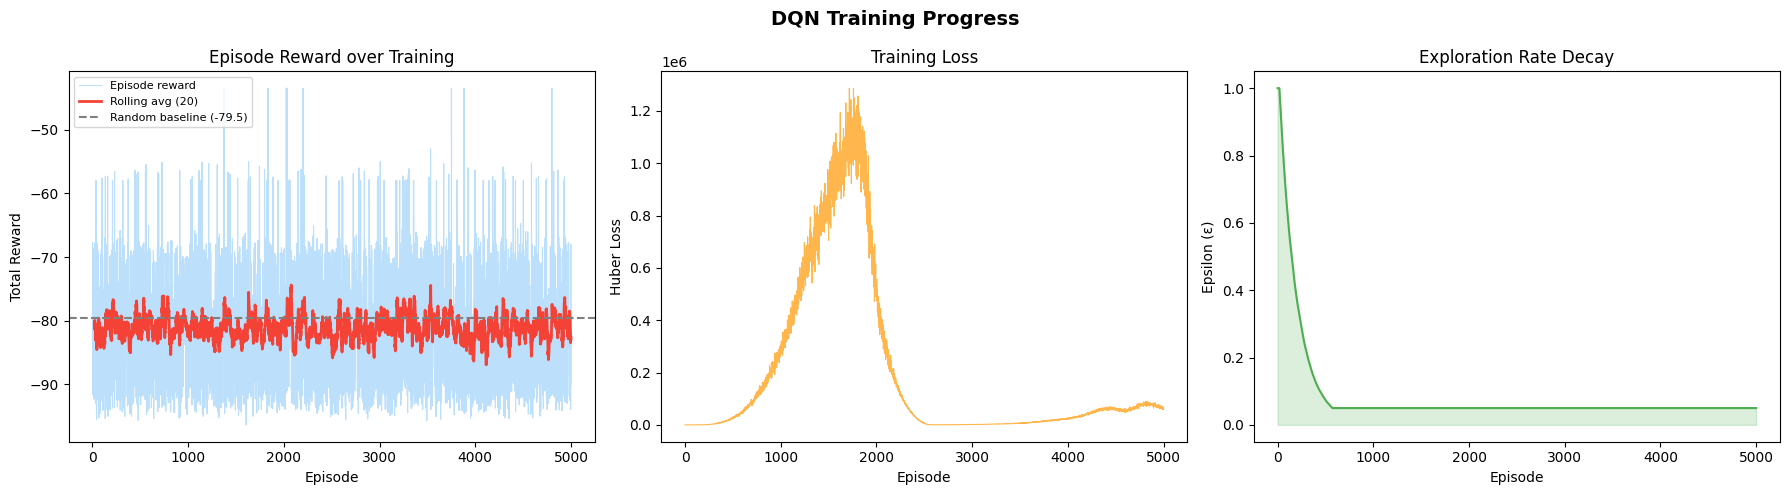


  TRAINING SUMMARY
  Episodes trained       : 5000
  Random baseline reward : -79.53
  DQN last-100 avg       : -80.67
  Improvement over random: -1.4%
  Target (proposal)      : ≥ 25% improvement
  Status                 : ⚠️  Train more episodes to reach target


In [31]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Training Visualisation                                    ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 10 : TRAINING RESULTS & VISUALISATION")
print("=" * 55)

# Smooth rewards with rolling average
window = 20
smoothed = pd.Series(reward_history).rolling(window).mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("DQN Training Progress", fontsize=14, fontweight="bold")

# ── Reward curve ───────────────────────────────────────────────────────
axes[0].plot(reward_history, alpha=0.3, color="#2196F3", linewidth=0.8,
             label="Episode reward")
axes[0].plot(smoothed,       color="#F44336", linewidth=2,
             label=f"Rolling avg ({window})")
axes[0].axhline(y=baseline_mean, color="gray", linestyle="--",
                linewidth=1.5, label=f"Random baseline ({baseline_mean:.1f})")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")
axes[0].set_title("Episode Reward over Training")
axes[0].legend(fontsize=8)

# ── Loss curve ────────────────────────────────────────────────────────
axes[1].plot(loss_history, color="#FF9800", linewidth=0.8, alpha=0.7)
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Huber Loss")
axes[1].set_title("Training Loss")

# ── Epsilon decay ─────────────────────────────────────────────────────
axes[2].plot(epsilon_history, color="#4CAF50", linewidth=1.5)
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Epsilon (ε)")
axes[2].set_title("Exploration Rate Decay")
axes[2].fill_between(range(len(epsilon_history)), epsilon_history,
                     alpha=0.2, color="#4CAF50")

plt.tight_layout()
plt.savefig("dqn_training_progress.png", dpi=150)
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────
last_100_mean = np.mean(reward_history[-100:])
improvement   = ((last_100_mean - baseline_mean) / abs(baseline_mean)) * 100

print(f"\n{'='*45}")
print(f"  TRAINING SUMMARY")
print(f"{'='*45}")
print(f"  Episodes trained       : {N_EPISODES}")
print(f"  Random baseline reward : {baseline_mean:.2f}")
print(f"  DQN last-100 avg       : {last_100_mean:.2f}")
print(f"  Improvement over random: {improvement:+.1f}%")
print(f"  Target (proposal)      : ≥ 25% improvement")
status = "✅  TARGET MET!" if improvement >= 25 else "⚠️  Train more episodes to reach target"
print(f"  Status                 : {status}")
print(f"{'='*45}")

STEP 11 : EVALUATE — DQN Route vs Random Route

📊  Evaluation over 20 episodes:
   DQN  mean reward           : -82.78  ± 6.43
   Rand mean reward           : -81.51  ± 7.21
   Route efficiency gain      : -1.6%
   High-VFA farms first (DQN) : 0.0 / 4
   High-VFA farms first (Rand): 0.0 / 4


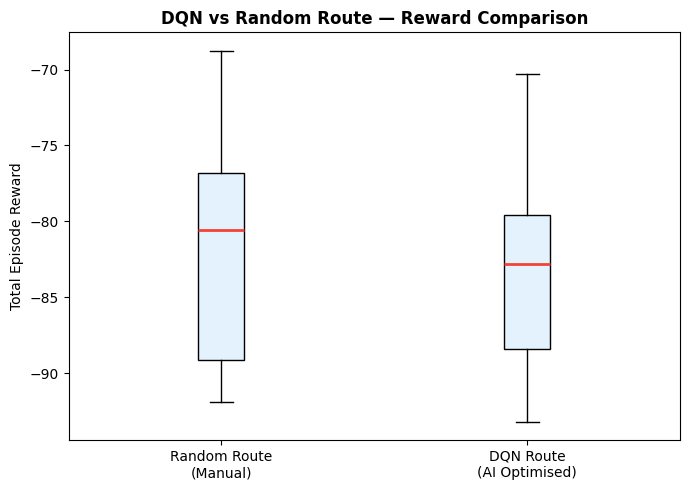

In [33]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — Evaluate: DQN Route vs Random Route                       ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 11 : EVALUATE — DQN Route vs Random Route")
print("=" * 55)

agent.online_net.load_state_dict(
    torch.load("best_dqn_model.pth", map_location=DEVICE))
agent.online_net.eval()
agent.epsilon = 0.0

N_EVAL = 20
dqn_rewards, rand_rewards = [], []
dqn_high_vfa_first, rand_high_vfa_first = [], []

for _ in range(N_EVAL):
    # ── DQN route ────────────────────────────────────────────────────
    state    = env.reset()
    total_r  = 0.0
    visit_order = []
    done = False

    while not done:
        valid = env._valid()           # ← fixed
        if not valid:
            break
        action = agent.select_action(state, valid)
        state, r, done, info = env.step(action)
        total_r += r
        visit_order.append(info.get("vfa", 0))

    half     = len(visit_order) // 2
    hv_first = sum(1 for v in visit_order[:half] if v > 0.50)
    dqn_rewards.append(total_r)
    dqn_high_vfa_first.append(hv_first)

    # ── Random route ─────────────────────────────────────────────────
    env.reset()
    r_total = 0.0
    r_order = []
    r_visited = list(range(env.n))
    random.shuffle(r_visited)

    for a in r_visited:
        if a not in env._valid():      # ← fixed
            continue
        _, r, done, info = env.step(a)
        r_total += r
        r_order.append(info.get("vfa", 0))
        if done:
            break

    r_hv = sum(1 for v in r_order[:half] if v > 0.50)
    rand_rewards.append(r_total)
    rand_high_vfa_first.append(r_hv)

dqn_mean  = np.mean(dqn_rewards)
rand_mean = np.mean(rand_rewards)
improv    = ((dqn_mean - rand_mean) / abs(rand_mean)) * 100

print(f"\n📊  Evaluation over {N_EVAL} episodes:")
print(f"   DQN  mean reward           : {dqn_mean:.2f}  ± {np.std(dqn_rewards):.2f}")
print(f"   Rand mean reward           : {rand_mean:.2f}  ± {np.std(rand_rewards):.2f}")
print(f"   Route efficiency gain      : {improv:+.1f}%")
print(f"   High-VFA farms first (DQN) : {np.mean(dqn_high_vfa_first):.1f} / {half}")
print(f"   High-VFA farms first (Rand): {np.mean(rand_high_vfa_first):.1f} / {half}")

# ── Box plot comparison ───────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.boxplot([rand_rewards, dqn_rewards],
            labels=["Random Route\n(Manual)", "DQN Route\n(AI Optimised)"],
            patch_artist=True,
            boxprops=dict(facecolor="#E3F2FD"),
            medianprops=dict(color="#F44336", linewidth=2))
plt.ylabel("Total Episode Reward")
plt.title("DQN vs Random Route — Reward Comparison", fontweight="bold")
plt.tight_layout()
plt.savefig("dqn_vs_random_boxplot.png", dpi=150)
plt.show()

In [36]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — Route Map Visualisation (Folium)                          ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 12 : ROUTE MAP VISUALISATION")
print("=" * 55)

try:
    import folium

    # ── Run one DQN episode and record the stop order ─────────────
    agent.epsilon = 0.0
    state = env.reset()
    route = []
    done  = False

    while not done:
        valid = env._valid()           # ← fixed
        if not valid:
            break
        action = agent.select_action(state, valid)
        farm   = env.farmers.iloc[action]
        state, r, done, info = env.step(action)
        route.append({
            "lat"   : float(farm["lat"]),
            "lng"   : float(farm["lng"]),
            "vfa"   : round(float(farm["avg_vfa"]), 3),
            "drc"   : round(float(farm["avg_drc"]), 3),
            "vol"   : round(float(farm["avg_vol"]), 1),
            "reward": round(r, 2),
            "order" : len(route) + 1,
        })

    # ── Build map ──────────────────────────────────────────────────
    m = folium.Map(location=[DEPOT_LAT, DEPOT_LNG],
                   zoom_start=10, tiles="OpenStreetMap")

    # Depot marker
    folium.Marker(
        location=[DEPOT_LAT, DEPOT_LNG],
        popup="🏭 Depot / Factory",
        icon=folium.Icon(color="black", icon="home")
    ).add_to(m)

    # Farm markers coloured by VFA urgency
    def vfa_color(vfa):
        if vfa > 0.85:  return "red"
        if vfa >= 0.50: return "orange"
        return "green"

    path_coords = [[DEPOT_LAT, DEPOT_LNG]]

    for stop in route:
        path_coords.append([stop["lat"], stop["lng"]])
        popup_html = (
            f"<b>Stop #{stop['order']}</b><br>"
            f"VFA : {stop['vfa']}<br>"
            f"DRC : {stop['drc']}<br>"
            f"Vol : {stop['vol']} L<br>"
            f"Reward : {stop['reward']}"
        )
        folium.CircleMarker(
            location=[stop["lat"], stop["lng"]],
            radius=9,
            color=vfa_color(stop["vfa"]),
            fill=True,
            fill_opacity=0.85,
            popup=folium.Popup(popup_html, max_width=200),
            tooltip=f"#{stop['order']}  VFA={stop['vfa']}"
        ).add_to(m)

    # Return to depot
    path_coords.append([DEPOT_LAT, DEPOT_LNG])

    folium.PolyLine(
        path_coords,
        color="#2196F3",
        weight=2.5,
        opacity=0.8,
        tooltip="DQN Optimised Route"
    ).add_to(m)

    # Legend
    legend_html = """
    <div style="position:fixed; bottom:30px; left:30px; z-index:1000;
                background:white; padding:10px; border-radius:8px;
                border:2px solid grey; font-size:13px;">
      <b>VFA Urgency</b><br>
      🔴 Urgent  (VFA &gt; 0.85)<br>
      🟠 Moderate (0.50 – 0.85)<br>
      🟢 Low  (VFA &lt; 0.50)
    </div>"""
    m.get_root().html.add_child(folium.Element(legend_html))

    m.save("dqn_route_map.html")
    print("✅  Route map saved as  dqn_route_map.html")
    print(f"   Total stops plotted : {len(route)}")
    print("\n   Stop order summary:")
    for stop in route:
        urgency = ("🔴 URGENT  " if stop["vfa"] > 0.85
                   else "🟠 MODERATE" if stop["vfa"] >= 0.50
                   else "🟢 LOW     ")
        print(f"   Stop #{stop['order']}  {urgency}  "
              f"VFA={stop['vfa']}  Reward={stop['reward']}")

    # Display inline in Colab
    from IPython.display import IFrame, display
    display(IFrame("dqn_route_map.html", width=800, height=500))

except Exception as e:
    print(f"⚠️  Map rendering failed: {e}")

STEP 12 : ROUTE MAP VISUALISATION
✅  Route map saved as  dqn_route_map.html
   Total stops plotted : 6

   Stop order summary:
   Stop #1  🟢 LOW       VFA=0.028  Reward=-14.5
   Stop #2  🟢 LOW       VFA=0.027  Reward=-12.06
   Stop #3  🟢 LOW       VFA=0.092  Reward=-10.97
   Stop #4  🟢 LOW       VFA=0.095  Reward=-14.41
   Stop #5  🟢 LOW       VFA=0.025  Reward=-14.4
   Stop #6  🟢 LOW       VFA=0.061  Reward=-14.14


In [37]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 16 — Real-Time Inference Demo (simulates ESP32 input)          ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 13 : REAL-TIME INFERENCE DEMO")
print("          (simulates what the ESP32 sends live)")
print("=" * 55)

demo_readings = [
    # Scenario 1 — High VFA alert (urgent)
    {"pH_avg": 6.2, "turbidity_ntu": 80, "turbidity_log": np.log1p(80),
     "temperature_c": 31.5, "ammonia_content": 0.005,
     "color_score": 1, "days_since_tapped": 4,
     "expected_volume": 20, "season_index": 1,
     "seasonal_multiplier": 1.25, "shift_encoded": 1, "month": 4},
    # Scenario 2 — Good quality (deprioritise)
    {"pH_avg": 7.1, "turbidity_ntu": 15, "turbidity_log": np.log1p(15),
     "temperature_c": 26.0, "ammonia_content": 0.02,
     "color_score": 5, "days_since_tapped": 1,
     "expected_volume": 18, "season_index": 0,
     "seasonal_multiplier": 1.00, "shift_encoded": 0, "month": 1},
    # Scenario 3 — Moderate risk
    {"pH_avg": 6.7, "turbidity_ntu": 40, "turbidity_log": np.log1p(40),
     "temperature_c": 28.5, "ammonia_content": 0.012,
     "color_score": 3, "days_since_tapped": 2,
     "expected_volume": 12, "season_index": 4,
     "seasonal_multiplier": 1.18, "shift_encoded": 0, "month": 9},
]

scenarios = ["🔴 HIGH VFA — URGENT", "🟢 LOW VFA — FRESH", "🟠 MODERATE VFA"]

print(f"\n{'─'*60}")
for i, (reading, label) in enumerate(zip(demo_readings, scenarios), 1):
    result = predict_quality(reading)
    print(f"\n  Scenario {i}: {label}")
    print(f"    Temp={reading['temperature_c']}°C  "
          f"pH={reading['pH_avg']}  "
          f"Turbidity={reading['turbidity_ntu']} NTU  "
          f"Days tapped={reading['days_since_tapped']}")
    print(f"    → Predicted VFA  : {result['predicted_vfa']}")
    print(f"    → Predicted DRC  : {result['predicted_drc']}")
    print(f"    → Quality Grade  : {result['quality_grade']}")
    print(f"    → DQN Action     : {result['vfa_urgency']}")
print(f"{'─'*60}")

STEP 13 : REAL-TIME INFERENCE DEMO
          (simulates what the ESP32 sends live)

────────────────────────────────────────────────────────────

  Scenario 1: 🔴 HIGH VFA — URGENT
    Temp=31.5°C  pH=6.2  Turbidity=80 NTU  Days tapped=4
    → Predicted VFA  : 0.0542
    → Predicted DRC  : 57.1714
    → Quality Grade  : B
    → DQN Action     : 🟢  LOW      (-10 deprioritised)

  Scenario 2: 🟢 LOW VFA — FRESH
    Temp=26.0°C  pH=7.1  Turbidity=15 NTU  Days tapped=1
    → Predicted VFA  : 0.0232
    → Predicted DRC  : 60.656
    → Quality Grade  : A
    → DQN Action     : 🟢  LOW      (-10 deprioritised)

  Scenario 3: 🟠 MODERATE VFA
    Temp=28.5°C  pH=6.7  Turbidity=40 NTU  Days tapped=2
    → Predicted VFA  : 0.0263
    → Predicted DRC  : 58.4468
    → Quality Grade  : A
    → DQN Action     : 🟢  LOW      (-10 deprioritised)
────────────────────────────────────────────────────────────


In [38]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 17 — Save All Models                                           ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("STEP 14 : SAVE ALL MODELS")
print("=" * 55)

import pickle

# Save VFA Random Forest
with open("vfa_random_forest_model.pkl", "wb") as f:
    pickle.dump(vfa_model, f)

# Save DRC Gradient Boosting
with open("drc_gradient_boosting_model.pkl", "wb") as f:
    pickle.dump(drc_model, f)

# Save StandardScaler (IMPORTANT — must use same scaler at inference)
with open("feature_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# DQN already saved as best_dqn_model.pth
print("✅  Saved:")
print("   vfa_random_forest_model.pkl   ← VFA predictor")
print("   drc_gradient_boosting_model.pkl ← DRC predictor")
print("   feature_scaler.pkl            ← StandardScaler")
print("   best_dqn_model.pth            ← DQN route optimizer weights")

# Download all files to your computer
from google.colab import files
for fname in ["vfa_random_forest_model.pkl",
              "drc_gradient_boosting_model.pkl",
              "feature_scaler.pkl",
              "best_dqn_model.pth",
              "eda_overview.png",
              "correlation_heatmap.png",
              "vfa_feature_importance.png",
              "vfa_actual_vs_predicted.png",
              "dqn_training_progress.png",
              "dqn_vs_random_boxplot.png",
              "dqn_route_map.html"]:
    try:
        files.download(fname)
    except Exception:
        pass

print("\n🎉  All done! Check your downloads folder.")

STEP 14 : SAVE ALL MODELS
✅  Saved:
   vfa_random_forest_model.pkl   ← VFA predictor
   drc_gradient_boosting_model.pkl ← DRC predictor
   feature_scaler.pkl            ← StandardScaler
   best_dqn_model.pth            ← DQN route optimizer weights


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉  All done! Check your downloads folder.
